<div align="center">

<img alt="Institucion: Tec de Monterrey" src="https://img.shields.io/badge/Institucion-Tec%20de%20Monterrey-002D72">&nbsp;<img alt="Programa: MNA" src="https://img.shields.io/badge/Programa-MNA-0072CE">&nbsp;<img alt="Materia: Proyecto Integrador" src="https://img.shields.io/badge/Materia-Proyecto%20Integrador-F2A900">&nbsp;<img alt="Entregable: Avance 2" src="https://img.shields.io/badge/Entregable-Avance%202-1E40AF">

<img alt="Python: 3.12" src="https://img.shields.io/badge/Python-3.12-3776AB">&nbsp;<img alt="Jupyter: notebook" src="https://img.shields.io/badge/Jupyter-notebook-3776AB">&nbsp;<img alt="PyTorch: 2.4" src="https://img.shields.io/badge/PyTorch-2.4-3776AB">&nbsp;<img alt="Polars: 1.x" src="https://img.shields.io/badge/Polars-1.x-3776AB">

</div>

<h1 align="center">Avance 5 — Modelo Final</h1>
<p align="center"><strong>AgroSatCopilot</strong> · Cuantificación de superficies de cultivo por satélite</p>

<table align="center"><tr>
<td align="center" width="200"><img src="../../img/IsaacAvila.jpg" width="130" height="130" style="border-radius:50%;object-fit:contain;background:#f0f0f0"><br><strong>Carlos Isaac Ávila Gutiérrez</strong><br><code>A01796035</code><br><sub>ML / Data Scientist</sub></td>
<td align="center" width="200"><img src="../../img/AaronBocanegra.jpg" width="130" height="130" style="border-radius:50%;object-fit:contain;background:#f0f0f0"><br><strong>Carlos Aaron Bocanegra Buitrón</strong><br><code>A01796345</code><br><sub>Full-Stack / Backend</sub></td>
<td align="center" width="200"><img src="../../img/ArthurZizumbo.png" width="130" height="130" style="border-radius:50%;object-fit:contain;background:#f0f0f0"><br><strong>Arthur Jafed Zizumbo Velasco</strong><br><code>A01796363</code><br><sub>MLOps / Platform</sub></td>
</tr></table>

---

<strong>Construccion, seleccion y normalizacion de caracteristicas sobre Sentinel-2, PASTIS-R y AlphaEarth, con fusion multisensor a nivel de parcela y validacion cross-region.</strong>

<table>
<tr><td><strong>Equipo 17</strong></td><td>&nbsp;&nbsp;• <strong>Carlos Isaac Ávila Gutiérrez</strong> — <code>A01796035</code><br>&nbsp;&nbsp;• <strong>Carlos Aaron Bocanegra Buitrón</strong> — <code>A01796345</code><br>&nbsp;&nbsp;• <strong>Arthur Jafed Zizumbo Velasco</strong> — <code>A01796363</code></td></tr>
<tr><td><strong>Curso</strong></td><td>MNA — Tec de Monterrey · 01-jun → 7-jun-2026</td></tr>
<tr><td><strong>Sponsor académico</strong></td><td>Dr. Gerardo Jesús Camacho González · gjcamacho@tec.mx</td></tr>
<tr><td><strong>Fecha de entrega</strong></td><td>2026-06-07</td></tr>
</table>


# FarSLIP sobre PASTIS-R: ablación stage-1/stage-2 y comparación con AlphaEarth

**FarSLIP** (Li et al. 2025) es un modelo CLIP especializado en teledetección que se
entrena en dos etapas: pre-entrenamiento contrastivo global (stage 1) y, encima, el
**alineamiento región-categoría a nivel de objeto** (stage 2). El paper sostiene que
esa segunda etapa es la que da el salto en comprensión fina de la escena.

Este cuaderno responde dos preguntas **sobre nuestros propios datos PASTIS-R**:

1. **¿Aporta el stage 2?** Comparamos las dos variantes publicadas (mismo backbone
   ViT-B/16, descargadas de `ZhenShiL/FarSLIP`) sobre las mismas parcelas.
2. **¿Compite FarSLIP con AlphaEarth?** Medimos FarSLIP frente a AlphaEarth-2019 (el
   embedding que ya alimenta el baseline tabular) y frente a AlphaEarth-2018+2019
   (vista multi-año), para decidir su papel en el ensamble del próximo avance.

**Cómo se extrae FarSLIP**: para cada parcela tomamos la mediana temporal de su serie
Sentinel-2, recortamos la parcela a su máscara de instancia, la convertimos a una
imagen RGB de 224×224 y la pasamos por la torre visual de cada FarSLIP (embedding de
512 dimensiones, L2-normalizado). No hay datos sintéticos ni placeholders: los
embeddings se generan con los pesos oficiales sobre las imágenes reales de PASTIS-R.

**Métricas**: similitud coseno por parcela entre s1 y s2, separabilidad por clase con
un clasificador lineal (LogisticRegression, F1-macro 5-fold) en régimen balanceado y
completo, silhouette score, y la geometría de cada espacio proyectada a UMAP 2D.

In [1]:
PASTIS_SUBSET_PATH = "data/test_fixtures/pastis_eval_subset.parquet"
# Real embeddings extracted over PASTIS-R (France) with the official FarSLIP
# published (Li et al. 2025), ViT-B/16 variant. Stage-1 vs stage-2 ablation.
FARSLIP_S2_PATH = "data/farslip/embeddings_pastis.parquet"
FARSLIP_S1_PATH = "data/farslip/embeddings_pastis_s1.parquet"
FARSLIP_CHECKPOINT_S2 = "data/farslip/checkpoints/FarSLIP2_ViT-B-16.pt"
FARSLIP_CHECKPOINT_S1 = "data/farslip/checkpoints/FarSLIP1_ViT-B-16.pt"
# AlphaEarth per-parcel embeddings (64 dims) for the cross-extractor comparison
# that will inform the ensemble in the next avance: the 2019 space (the one that
# already feeds the tabular baseline) and the multi-year 2018+2019 space.
ALPHAEARTH_2019_PATH = "data/cache/gee/alphaearth_parcels_pastis_parcels_2019_85951.parquet"
ALPHAEARTH_2018_PATH = "data/cache/gee/alphaearth_parcels_parcels_2018_85951.parquet"
FIGURES_SUBDIR = "us-023-preview/04_farslip_eval_pastis"
REPORTS_SUBDIR = "baseline/04_farslip_eval_pastis"
RANDOM_STATE = 42
MLFLOW_EXPERIMENT = "baseline-04-farslip-s1-vs-s2"
# Two reads of separability:
#  - Balanced: EVAL_SAMPLE_PER_CLASS parcels per crop (fair F1-macro, no class
#    dominates), dropping classes below MIN_CLASS_SAMPLES so the 5-fold CV holds.
#  - Full: every parcel of the shared universe (no cap), to see separability on
#    the whole dataset (F1-macro is then penalized by the ~31x imbalance).
EVAL_SAMPLE_PER_CLASS = 500
MIN_CLASS_SAMPLES = 50

In [2]:
from __future__ import annotations

import os
import sys
from pathlib import Path

# Bootstrap: locate the repo root by searching for pyproject.toml before any
# `ml.*` import resolves.
_HERE = Path.cwd().resolve()
for _candidate in (_HERE, *_HERE.parents):
    if (_candidate / "pyproject.toml").is_file():
        if str(_candidate) not in sys.path:
            sys.path.insert(0, str(_candidate))
        break

import matplotlib.pyplot as plt
import polars as pl
from IPython.display import Markdown, display

from ml.eval.embedding_separability import (
    align_spaces_on_parcels,
    build_balanced_eval_set,
    combine_year_embeddings,
    eval_space,
    load_alphaearth_embeddings,
    plot_umap_by_class,
    space_matrix,
)
from ml.ingest.pastis_loader import PASTIS_R_CLASSES
from ml.utils.mlflow_utils import (
    resolve_tracking_uri,
    server_is_reachable,
    track_experiment,
)
from ml.utils.notebook_bootstrap import setup_notebook
from ml.utils.parcel_id import canonical_parcel_id

env = setup_notebook(figures_subdir=FIGURES_SUBDIR, reports_subdir=REPORTS_SUBDIR)
display(Markdown(env.summary_markdown()))

# Chdir to the repo root so the relative paths from the `parameters` cell resolve
# the same regardless of where the kernel was launched (VS Code opens with cwd =
# the notebook folder). Keeps the papermill contract and the figure/report dirs
# anchored to the repo, not a temp folder.
os.chdir(env.repo)
display(Markdown(f"**cwd anclado al repo root**: `{env.repo}`"))

| Recurso | Estado |
|---|---|
| Repo root | `C:\Users\arthu\Proyectos\MNA\agro_sat_copilot` |
| Figures dir | `paper\figures\us-023-preview\04_farslip_eval_pastis` |
| Reports dir | `reports\baseline\04_farslip_eval_pastis` |
| Gemini API key | presente |
| Earth Engine | configurado |
| GEE project | `agrosat-copilot` |

**cwd anclado al repo root**: `C:\Users\arthu\Proyectos\MNA\agro_sat_copilot`

### Trazabilidad MLflow

Cada espacio y régimen (FarSLIP-s1/s2 y AlphaEarth-2019/2018+2019, en balanceado y
completo) abre un run propio en el experimento `baseline-04-farslip-s1-vs-s2`. La
métrica principal es el F1-macro promedio del 5-fold estratificado: cuanto mayor,
mejor separa el espacio los cultivos PASTIS.

In [3]:
# Robust tracking URI resolution: if MLFLOW_TRACKING_URI is set in `.env.local`
# but the server is unreachable (Docker off, container stopped), fall back to
# `file:./mlruns` so the notebook does not stop.
_candidate_uri = resolve_tracking_uri(None, probe_server=False)
if _candidate_uri.startswith(("http://", "https://")) and not server_is_reachable(_candidate_uri):
    mlflow_uri = "file:./mlruns"
    display(Markdown(
        f"> Servidor MLflow `{_candidate_uri}` no responde. "
        "Caigo a tracking local `file:./mlruns`. "
        "Para registrar en el server, ejecuta `docker compose up -d mlflow` "
        "antes de re-ejecutar las celdas MLflow."
    ))
else:
    mlflow_uri = _candidate_uri
display(Markdown(
    f"**MLflow tracking URI**: `{mlflow_uri}` · **Experimento**: `{MLFLOW_EXPERIMENT}`"
))
MLFLOW_RUN_IDS: dict[str, str] = {}

**MLflow tracking URI**: `http://localhost:5010` · **Experimento**: `baseline-04-farslip-s1-vs-s2`

## 1. Carga de los espacios de embedding y conjuntos de evaluación

Cargamos los cuatro espacios que vamos a comparar, todos a nivel de parcela y con
el mismo identificador `parcel_id`:

- **FarSLIP-s1**: torre visual ViT-B/16, solo pre-entrenamiento contrastivo global.
- **FarSLIP-s2**: la misma torre + alineamiento región-categoría (modelo completo).
- **AlphaEarth 2019**: el embedding fundacional de 64 dimensiones que ya alimenta el
  baseline tabular.
- **AlphaEarth 2018+2019**: la concatenación de los dos años (128 dimensiones), para
  ver si la vista multi-año aporta señal de cara al ensamble del próximo avance.

Sobre los parcels comunes a todos los espacios definimos dos conjuntos de
evaluación: uno **balanceado** (tope `EVAL_SAMPLE_PER_CLASS` por cultivo, para un
F1-macro justo) y el **universo completo** (todas las parcelas, sin tope). Reportar
ambos evita que el balanceo esconda el efecto del desbalance real.

In [4]:
# Load the four embedding spaces. FarSLIP parquets carry parcel_id + class_id +
# emb_000..511; AlphaEarth parquets carry parcel_id + dim_00..63 (per year).
for _p in (FARSLIP_S1_PATH, FARSLIP_S2_PATH, ALPHAEARTH_2019_PATH, ALPHAEARTH_2018_PATH):
    if not Path(_p).is_file():
        raise FileNotFoundError(
            f"Embedding parquet no encontrado: {_p}. Para FarSLIP, genera los "
            "embeddings con scripts/extract_farslip_official_pastis.py; para "
            "AlphaEarth, materializa el cache GEE por parcela."
        )

farslip_s1 = canonical_parcel_id(pl.read_parquet(FARSLIP_S1_PATH))
farslip_s2 = canonical_parcel_id(pl.read_parquet(FARSLIP_S2_PATH))
alphaearth_2019 = load_alphaearth_embeddings(ALPHAEARTH_2019_PATH, year_suffix="_2019")
alphaearth_2018 = load_alphaearth_embeddings(ALPHAEARTH_2018_PATH, year_suffix="_2018")
# Multi-year AlphaEarth: concatenate the 64+64 dims of 2018 and 2019 per parcel.
alphaearth_multi = combine_year_embeddings(alphaearth_2019, alphaearth_2018)

display(Markdown(
    "**Espacios cargados**:\n\n"
    f"- FarSLIP-s1: `{farslip_s1.shape}`\n"
    f"- FarSLIP-s2: `{farslip_s2.shape}`\n"
    f"- AlphaEarth 2019: `{alphaearth_2019.shape}`\n"
    f"- AlphaEarth 2018+2019: `{alphaearth_multi.shape}`"
))

# The shared label universe = parcels present in FarSLIP (carries class_id), which
# is the most restrictive space. Build the balanced eval set and the full set
# from it; both later inner-join against every space.
_universe = farslip_s2.select(["parcel_id", "class_id"])
balanced_labels, _dropped = build_balanced_eval_set(
    _universe,
    per_class_cap=EVAL_SAMPLE_PER_CLASS,
    min_class_samples=MIN_CLASS_SAMPLES,
    random_state=RANDOM_STATE,
    class_names=PASTIS_R_CLASSES,
)
full_labels = canonical_parcel_id(_universe).with_columns(
    pl.col("class_id")
    .map_elements(lambda c: PASTIS_R_CLASSES.get(int(c), f"c{int(c)}"), return_dtype=pl.Utf8)
    .alias("class_name")
)

display(Markdown(
    f"**Conjunto balanceado**: `{balanced_labels.height}` parcelas "
    f"(tope `{EVAL_SAMPLE_PER_CLASS}`/clase, `{balanced_labels['class_id'].n_unique()}` clases)  ·  "
    f"**Universo completo**: `{full_labels.height}` parcelas "
    f"(`{full_labels['class_id'].n_unique()}` clases)."
))
if _dropped:
    display(Markdown(
        f"> Clases descartadas del balanceado por < `{MIN_CLASS_SAMPLES}` parcelas: `{_dropped}`."
    ))
display(Markdown("**Distribución de clases (balanceado)**:"))
display(
    balanced_labels.group_by("class_id", "class_name").len().sort("len", descending=True)
)

**Espacios cargados**:

- FarSLIP-s1: `(81663, 515)`
- FarSLIP-s2: `(81663, 515)`
- AlphaEarth 2019: `(85951, 65)`
- AlphaEarth 2018+2019: `(85951, 129)`

**Conjunto balanceado**: `9000` parcelas (tope `500`/clase, `18` clases)  ·  **Universo completo**: `81663` parcelas (`18` clases).

**Distribución de clases (balanceado)**:

class_id,class_name,len
i64,str,u32
7,"""Sunflower""",500
6,"""Spring barley""",500
12,"""Fruits, vegetables, flowers""",500
8,"""Grapevine""",500
2,"""Soft winter wheat""",500
17,"""Mixed cereal""",500
15,"""Soybeans""",500
3,"""Corn""",500
4,"""Winter barley""",500


## 2. Similitud coseno entre FarSLIP-s2 y FarSLIP-s1 por parcela

Cuánto se mueve el embedding de cada parcela al añadir la segunda etapa. Coseno
cercano a 1 = el alineamiento región-categoría apenas cambió esa parcela; valores
más bajos = el stage 2 reorganizó su representación.

**Coseno s2 vs s1** sobre `9000` parcelas: mediana `0.988`, mínimo `0.969`.

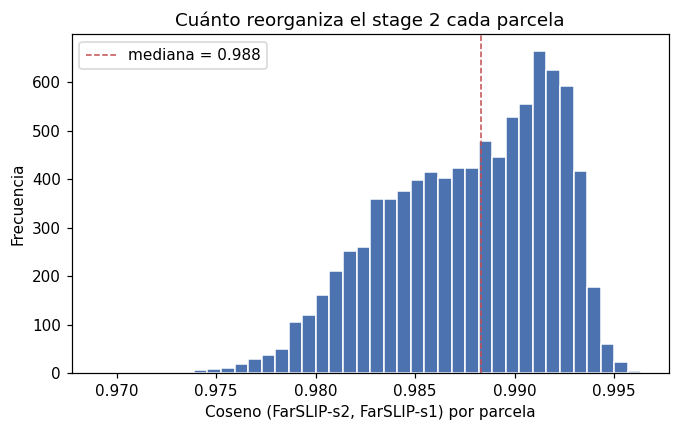

In [5]:
import numpy as np

# Align FarSLIP-s1 and s2 on the balanced parcels (same backbone, same parcels:
# a clean stage-1 vs stage-2 comparison). Embeddings are L2-normalized, so the
# row-wise cosine is the dot product.
_cos_merged, _cos_cols = align_spaces_on_parcels(
    balanced_labels, {"s1": (farslip_s1, "emb_"), "s2": (farslip_s2, "emb_")}
)
_s1_mat = space_matrix(_cos_merged, _cos_cols["s1"])
_s2_mat = space_matrix(_cos_merged, _cos_cols["s2"])
cosines = (_s1_mat * _s2_mat).sum(axis=1)

fig, ax = plt.subplots(figsize=(7, 4), dpi=110)
ax.hist(cosines, bins=40, color="#4C72B0", edgecolor="white")
ax.set_xlabel("Coseno (FarSLIP-s2, FarSLIP-s1) por parcela")
ax.set_ylabel("Frecuencia")
ax.set_title("Cuánto reorganiza el stage 2 cada parcela")
ax.axvline(float(np.median(cosines)), color="#C44E52", linestyle="--", linewidth=1,
           label=f"mediana = {np.median(cosines):.3f}")
ax.legend()
fig.savefig(env.figures_dir / "cosine_farslip_s2_vs_s1.png", bbox_inches="tight")
display(Markdown(
    f"**Coseno s2 vs s1** sobre `{_cos_merged.height}` parcelas: "
    f"mediana `{np.median(cosines):.3f}`, mínimo `{cosines.min():.3f}`."
))
display(fig)
plt.close(fig)

## 3. Separabilidad por clase de los cuatro espacios

Para cada espacio entrenamos un clasificador lineal (LogisticRegression, F1-macro
con validación cruzada estratificada de 5 folds) sobre los cultivos y medimos el
silhouette score. Lo hacemos en dos regímenes sobre exactamente las mismas
parcelas y etiquetas:

- **Balanceado** (`EVAL_SAMPLE_PER_CLASS`/clase): F1-macro justo, sin que las clases
  mayoritarias dominen.
- **Universo completo** (todas las parcelas): muestra la separabilidad real sobre
  todo el dataset; el F1-macro baja porque el desbalance ~31x castiga las clases
  minoritarias.

Comparamos FarSLIP-s1, FarSLIP-s2, AlphaEarth-2019 y AlphaEarth-2018+2019. El
contraste con AlphaEarth es el que importa de cara al ensamble del próximo avance:
dice si FarSLIP aporta señal por encima del embedding que ya usamos.

In [6]:
import mlflow

# The four spaces to compare, with their column prefixes.
_SPACES = {
    "farslip_s1": (farslip_s1, "emb_"),
    "farslip_s2": (farslip_s2, "emb_"),
    "alphaearth_2019": (alphaearth_2019, "dim_"),
    "alphaearth_2018_2019": (alphaearth_multi, "dim_"),
}
_LABELS = {"FarSLIP-s1": "farslip_s1", "FarSLIP-s2": "farslip_s2",
           "AlphaEarth-2019": "alphaearth_2019", "AlphaEarth-2018+2019": "alphaearth_2018_2019"}

rows = []
for regime, labels_df in [("balanceado", balanced_labels), ("completo", full_labels)]:
    merged, cols = align_spaces_on_parcels(labels_df, _SPACES)
    y = merged["class_id"].to_numpy()
    for pretty, key in _LABELS.items():
        res = eval_space(space_matrix(merged, cols[key]), y, label=f"{pretty} [{regime}]")
        rows.append({
            "espacio": pretty, "regimen": regime,
            "f1_macro": round(res.f1_macro_mean, 4), "f1_std": round(res.f1_macro_std, 4),
            "silhouette": round(res.silhouette, 4), "n": res.n_samples, "dims": res.n_dims,
        })
        with track_experiment(
            experiment_name=MLFLOW_EXPERIMENT,
            run_name=f"04-sep-{key}-{regime}",
            tracking_uri=mlflow_uri,
            probe_server=False,
        ) as run:
            mlflow.log_params({"space": key, "regime": regime, "n_dims": res.n_dims,
                               "classifier": "LogisticRegression", "cv_splits": 5})
            mlflow.log_metrics({"f1_macro_mean": res.f1_macro_mean,
                                "f1_macro_std": res.f1_macro_std, "silhouette": res.silhouette})
            MLFLOW_RUN_IDS[f"{key}-{regime}"] = run.info.run_id

separability = pl.DataFrame(rows).sort(["regimen", "f1_macro"], descending=[False, True])
separability.write_parquet(env.reports_dir / "separability_comparison.parquet")
display(Markdown("**Separabilidad por espacio y régimen** (F1-macro mayor = mejor):"))
display(separability)

2026-06-04 13:00:31 [info     ] embedding_space_evaluated      f1_macro_mean=0.16198655051346186 label='FarSLIP-s1 [balanceado]' n_dims=512 n_samples=5449 silhouette=-0.04268377709428389


2026-06-04 13:01:56 [info     ] mlflow_run_started             code_version=c64626360e1859fadd30df47c2f746c2a12c0455 data_version=untracked experiment=baseline-04-farslip-s1-vs-s2 run_id=34a70a0c9afb4b9bb32a8605fde98861 run_name=04-sep-farslip_s1-balanceado tracking_uri=http://localhost:5010


🏃 View run 04-sep-farslip_s1-balanceado at: http://localhost:5010/#/experiments/8/runs/34a70a0c9afb4b9bb32a8605fde98861
🧪 View experiment at: http://localhost:5010/#/experiments/8


2026-06-04 13:03:24 [info     ] embedding_space_evaluated      f1_macro_mean=0.16311990431481355 label='FarSLIP-s2 [balanceado]' n_dims=512 n_samples=5449 silhouette=-0.0448889192523237


2026-06-04 13:04:49 [info     ] mlflow_run_started             code_version=c64626360e1859fadd30df47c2f746c2a12c0455 data_version=untracked experiment=baseline-04-farslip-s1-vs-s2 run_id=d445c60037e9462c99e3840ed45d088a run_name=04-sep-farslip_s2-balanceado tracking_uri=http://localhost:5010


...

2026-06-04 13:21:20 [info     ] embedding_space_evaluated      f1_macro_mean=0.1739744658556376 label='AlphaEarth-2018+2019 [completo]' n_dims=128 n_samples=50495 silhouette=-0.09357926968542832


2026-06-04 13:22:44 [info     ] mlflow_run_started             code_version=c64626360e1859fadd30df47c2f746c2a12c0455 data_version=untracked experiment=baseline-04-farslip-s1-vs-s2 run_id=8c98ac38d5f545a68fe8063b779eeff8 run_name=04-sep-alphaearth_2018_2019-completo tracking_uri=http://localhost:5010


🏃 View run 04-sep-alphaearth_2018_2019-completo at: http://localhost:5010/#/experiments/8/runs/8c98ac38d5f545a68fe8063b779eeff8
🧪 View experiment at: http://localhost:5010/#/experiments/8


**Separabilidad por espacio y régimen** (F1-macro mayor = mejor):

espacio,regimen,f1_macro,f1_std,silhouette,n,dims
str,str,f64,f64,f64,i64,i64
"""AlphaEarth-2018+2019""","""balanceado""",0.2325,0.0145,-0.0804,5449,128
"""AlphaEarth-2019""","""balanceado""",0.2239,0.019,-0.0861,5449,64
"""FarSLIP-s2""","""balanceado""",0.1631,0.0133,-0.0449,5449,512
"""FarSLIP-s1""","""balanceado""",0.162,0.0117,-0.0427,5449,512
"""AlphaEarth-2018+2019""","""completo""",0.174,0.0025,-0.0936,50495,128
"""AlphaEarth-2019""","""completo""",0.1632,0.0026,-0.0969,50495,64
"""FarSLIP-s1""","""completo""",0.1339,0.0013,-0.0294,50495,512
"""FarSLIP-s2""","""completo""",0.1334,0.0013,-0.0313,50495,512


### 3.1 Gráfico comparativo de F1-macro por espacio

Barras de F1-macro por espacio en el régimen balanceado. La lectura clave es la
distancia entre las barras de FarSLIP y las de AlphaEarth: cuánta señal de cultivo
aporta cada familia de embedding.

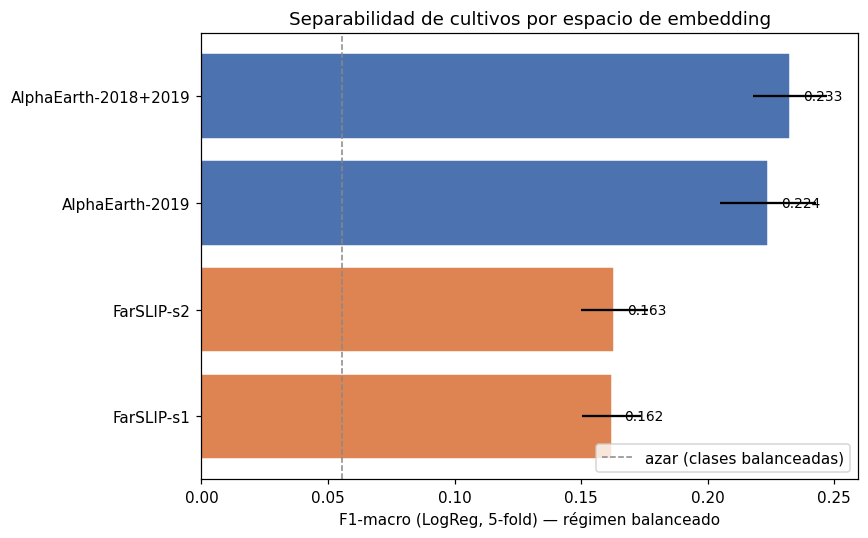

**MLflow runs**: `farslip_s1-balanceado=34a70a0c9a...`, `farslip_s2-balanceado=d445c60037...`, `alphaearth_2019-balanceado=e5683a8069...`, `alphaearth_2018_2019-balanceado=cb70c9c585...`, `farslip_s1-completo=edd0f8bc8a...`, `farslip_s2-completo=cc9824e273...`, `alphaearth_2019-completo=052a78d656...`, `alphaearth_2018_2019-completo=8c98ac38d5...`

In [7]:
_bal = separability.filter(pl.col("regimen") == "balanceado").sort("f1_macro", descending=True)
_colors = ["#DD8452" if "FarSLIP" in s else "#4C72B0" for s in _bal["espacio"]]

fig, ax = plt.subplots(figsize=(8, 5), dpi=110)
ax.barh(_bal["espacio"].to_list(), _bal["f1_macro"].to_list(),
        xerr=_bal["f1_std"].to_list(), color=_colors, edgecolor="white")
ax.set_xlabel("F1-macro (LogReg, 5-fold) — régimen balanceado")
ax.set_title("Separabilidad de cultivos por espacio de embedding")
ax.axvline(1 / full_labels["class_id"].n_unique(), color="#888", linestyle="--", linewidth=1,
           label="azar (clases balanceadas)")
for i, (v, s) in enumerate(zip(_bal["f1_macro"], _bal["f1_std"])):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)
ax.legend(loc="lower right")
ax.invert_yaxis()
fig.tight_layout()
fig.savefig(env.figures_dir / "f1_macro_by_space.png", bbox_inches="tight")
display(fig)
plt.close(fig)

display(Markdown("**MLflow runs**: " + ", ".join(
    f"`{k}={v[:10]}...`" for k, v in MLFLOW_RUN_IDS.items()
)))

## 4. Visualización UMAP de los espacios coloreados por clase

Cada punto es una parcela del conjunto balanceado proyectada al plano UMAP 2D del
espacio correspondiente, coloreada por su cultivo real. Comparamos los dos FarSLIP
contra AlphaEarth-2019: si AlphaEarth forma clusters por cultivo más nítidos que
FarSLIP, confirma visualmente la diferencia de separabilidad de la tabla anterior.

2026-06-04 13:24:39 [info     ] umap_2d_fitted                 n_features=512 n_neighbors=15 n_samples=5449 random_state=42


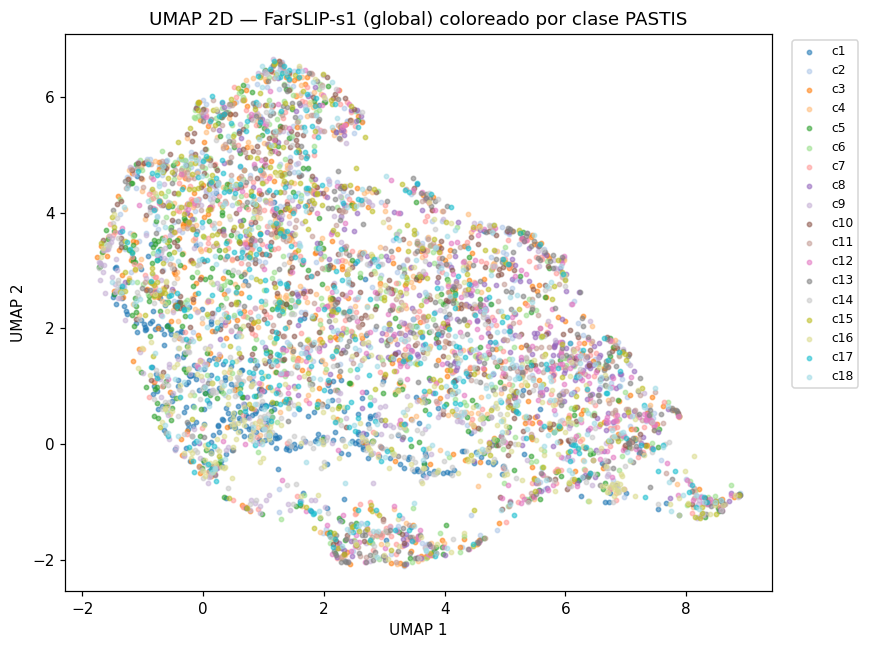

2026-06-04 13:24:45 [info     ] umap_2d_fitted                 n_features=512 n_neighbors=15 n_samples=5449 random_state=42


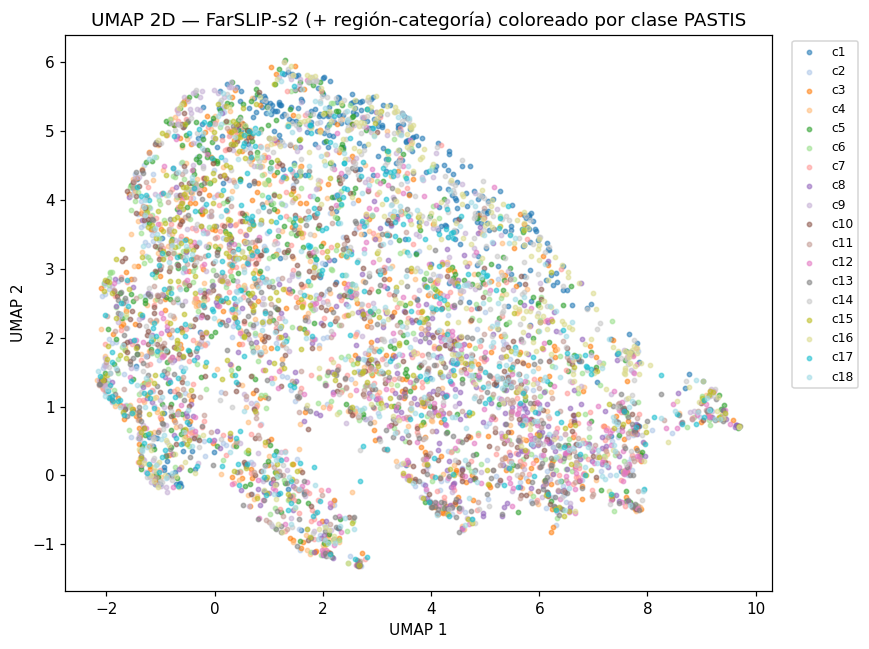

2026-06-04 13:24:50 [info     ] umap_2d_fitted                 n_features=64 n_neighbors=15 n_samples=5449 random_state=42


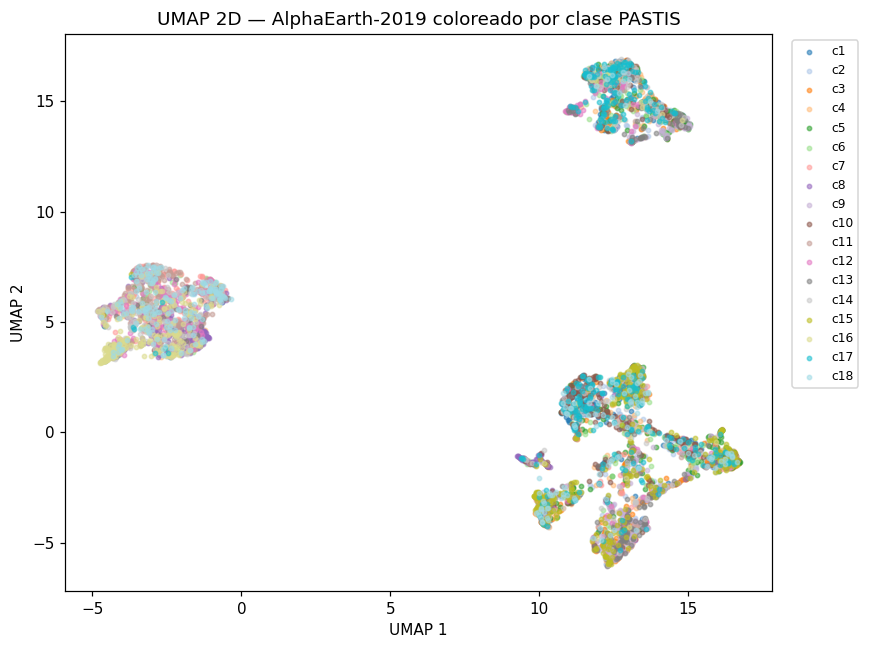

In [8]:
# Project three spaces over the same balanced parcels: the two FarSLIP variants
# and AlphaEarth-2019. plot_umap_by_class handles the UMAP fit + class colouring.
_umap_merged, _umap_cols = align_spaces_on_parcels(
    balanced_labels,
    {"s1": (farslip_s1, "emb_"), "s2": (farslip_s2, "emb_"), "ae": (alphaearth_2019, "dim_")},
)
_y_umap = _umap_merged["class_id"].to_numpy()

for key, pretty, fname in [
    ("s1", "FarSLIP-s1 (global)", "umap_farslip_s1_by_class.png"),
    ("s2", "FarSLIP-s2 (+ región-categoría)", "umap_farslip_s2_by_class.png"),
    ("ae", "AlphaEarth-2019", "umap_alphaearth_2019_by_class.png"),
]:
    fig = plot_umap_by_class(
        space_matrix(_umap_merged, _umap_cols[key]),
        _y_umap,
        title=f"UMAP 2D — {pretty} coloreado por clase PASTIS",
        out_path=env.figures_dir / fname,
        random_state=RANDOM_STATE,
    )
    display(fig)
    plt.close(fig)

## Conclusiones

Este cuaderno respondió dos preguntas sobre las parcelas reales de PASTIS-R: si la
segunda etapa de FarSLIP aporta, y cómo se compara FarSLIP con AlphaEarth de cara al
ensamble. Los cuatro espacios se evaluaron sobre exactamente las mismas parcelas —
`5449` en el régimen balanceado (las comunes a los cuatro) y `50495` en el universo
completo — así que las comparaciones son limpias.

**1. La segunda etapa de FarSLIP no aporta señal de cultivo medible.** FarSLIP-s1
(solo global) y FarSLIP-s2 (modelo completo) rinden lo mismo: F1-macro `0,162` vs
`0,163` balanceado (Δ `+0,001`, dentro del ruido `±0,012`) y `0,134` vs `0,133` en el
universo completo. El alineamiento región-categoría que da el salto a FarSLIP en los
benchmarks de detección de objetos del paper **no se traslada** a separar cultivos de
PASTIS. Para cualquier uso futuro basta s1, que es más barato.

**2. AlphaEarth supera a FarSLIP con holgura, y con muchas menos dimensiones.** En el
régimen balanceado AlphaEarth-2019 (64 dims) alcanza F1-macro `0,224` frente al `0,163`
de FarSLIP-s2 (512 dims); en el universo completo, `0,163` vs `0,133`. AlphaEarth es el
embedding más informativo para cultivos por un margen amplio (`+0,06` balanceado) y con
un vector ocho veces más corto. Es esperable: AlphaEarth es un foundation model
entrenado sobre series multi-temporales y multi-banda, mientras FarSLIP solo ve una
imagen RGB promediada en el tiempo, que descarta el calendario de crecimiento del
cultivo.

**3. La vista multi-año de AlphaEarth aporta una mejora pequeña pero consistente.**
AlphaEarth-2018+2019 (128 dims, concatenación de los dos años) sube a F1-macro `0,233`
balanceado y `0,174` completo, frente a `0,224` / `0,163` de solo 2019: una ganancia de
`+0,009` / `+0,011`. El año extra añade contexto interanual aprovechable.

**Lectura para el ensamble** (próximo avance):

- **AlphaEarth es el embedding base, no FarSLIP.** La diferencia de separabilidad es
  clara y robusta en ambos regímenes.
- **Vale la pena la vista 2018+2019**: el multi-año mejora de forma consistente, así que
  el ensamble debería alimentarse del AlphaEarth multi-temporal, no solo del año único.
- **FarSLIP queda descartado** como bloque del baseline tabular y como clasificador de
  cultivos. Su valor potencial sería como descriptor de contexto espacial dentro de una
  fusión, nunca como clasificador por sí solo; y entre s1 y s2 da igual cuál se use.

**Por qué FarSLIP rinde tan por debajo de su fama**: es un modelo **RGB de una sola
imagen** (mediana temporal), no consume la serie temporal completa ni las diez bandas
espectrales. Distinguir trigo de cebada o maíz de girasol depende sobre todo del
calendario de crecimiento, justo lo que una imagen RGB promediada descarta. Y su stage 2
se entrena para alinear regiones de objetos con categorías de detección (aviones,
barcos, edificios), un objetivo sin contraparte en parcelas agrícolas a 10 m.

**Nota de método**: todas las cifras son F1-macro de un clasificador lineal
(LogisticRegression, 5-fold estratificado) sobre el espacio de embedding crudo, sin
ajuste fino. Miden la calidad intrínseca del espacio, no el rendimiento final de un
modelo entrenado a fondo; el silhouette negativo en todos los casos indica que ningún
embedding forma clusters por cultivo perfectamente nítidos a esta resolución. Como
referencia, los modelos temporales densos del Avance 4 (TSViT-pheno, F1-macro `0,75`)
quedan muy por encima de cualquiera de estos embeddings tabulares.